# Métodos Numéricos I — Notebook da Aula 4
## Splines: limitações da interpolação global, interpolação por partes e splines cúbicos

**Programa:** PPGMC / UESC  
**Referências-base:** Burden & Faires cap. 3; Kiusalaas cap. 3.

Este notebook foi preparado para apoiar a **Aula 4 — Splines**.

## Objetivos
- entender as **limitações da interpolação polinomial global**;
- introduzir a ideia de **interpolação por partes**;
- construir e interpretar **splines cúbicos**;
- visualizar as **condições de continuidade**;
- aplicar splines em **modelagem de dados**.

## 1. Bibliotecas

Usaremos:
- `numpy` para cálculo numérico;
- `matplotlib` para visualização;
- `scipy.interpolate.CubicSpline` para construção computacional de splines cúbicos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

## 2. Motivação: por que não usar sempre um único polinômio global?

Na aula anterior vimos que a interpolação polinomial global pode funcionar bem em alguns casos, mas também pode apresentar problemas importantes:

- oscilações indesejadas;
- instabilidade numérica;
- sensibilidade aos pontos escolhidos;
- piora da aproximação perto das bordas.

O exemplo clássico é a **função de Runge**:

\[
f(x)=\frac{1}{1+25x^2}, \quad x\in[-1,1].
\]

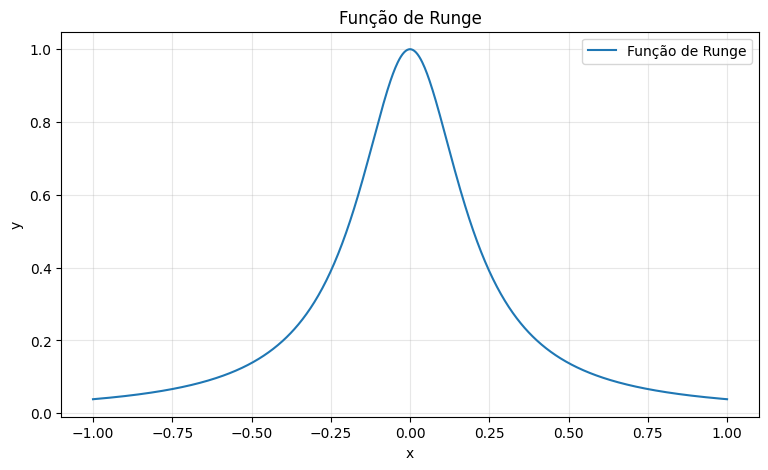

In [2]:
def runge(x):
    return 1 / (1 + 25*x**2)

x = np.linspace(-1, 1, 800)

plt.figure(figsize=(9,5))
plt.plot(x, runge(x), label="Função de Runge")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Função de Runge")
plt.legend()
plt.show()

## 3. Comparação inicial: polinômio global de alto grau

Vamos construir a interpolação polinomial global da função de Runge usando pontos igualmente espaçados.
Para isso, usaremos `numpy.polyfit`, que devolve os coeficientes do polinômio interpolador.

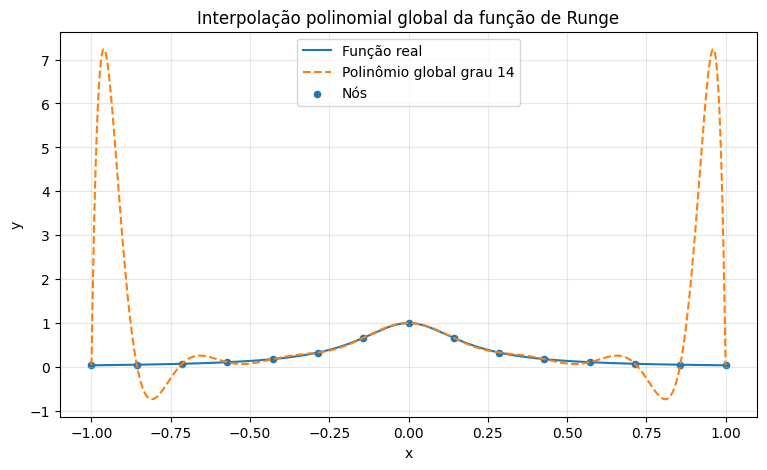

In [3]:
n = 15
xs = np.linspace(-1, 1, n)
ys = runge(xs)

coef_global = np.polyfit(xs, ys, deg=n-1)
p_global = np.poly1d(coef_global)

x_plot = np.linspace(-1, 1, 1200)
y_real = runge(x_plot)
y_global = p_global(x_plot)

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_real, label="Função real")
plt.plot(x_plot, y_global, "--", label=f"Polinômio global grau {n-1}")
plt.scatter(xs, ys, s=20, label="Nós")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolação polinomial global da função de Runge")
plt.legend()
plt.show()

### Comentário

Observe as oscilações perto das extremidades do intervalo.  
Esse é o **fenômeno de Runge**: aumentar o grau do polinômio global nem sempre melhora a aproximação.

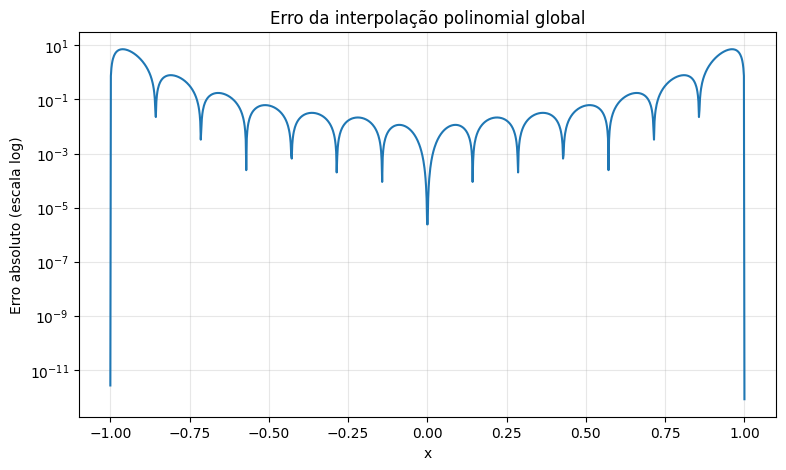

In [4]:
erro_global = np.abs(y_real - y_global)

plt.figure(figsize=(9,5))
plt.plot(x_plot, erro_global)
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("Erro absoluto (escala log)")
plt.title("Erro da interpolação polinomial global")
plt.show()

## 4. Ideia central da interpolação por partes

Em vez de construir **um único polinômio global**, podemos dividir o intervalo em subintervalos:

\[
[x_0,x_1], [x_1,x_2], \dots, [x_{n-1},x_n]
\]

e construir um polinômio simples em cada trecho.

Isso leva à **interpolação por partes**.

## 5. Primeiro passo: interpolação linear por partes

A forma mais simples de interpolação por partes é ligar os pontos por segmentos de reta.

Ela evita grandes oscilações, mas não produz uma curva suave nas junções.

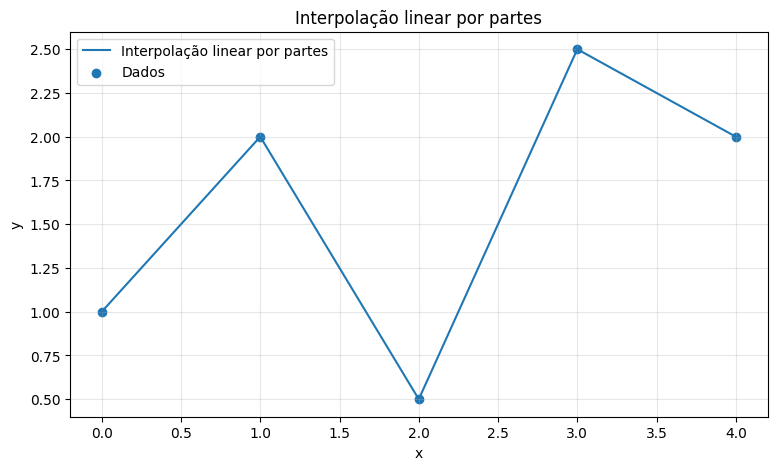

In [5]:
x_data = np.array([0, 1, 2, 3, 4], dtype=float)
y_data = np.array([1.0, 2.0, 0.5, 2.5, 2.0], dtype=float)

x_plot = np.linspace(x_data.min(), x_data.max(), 600)
y_linear = np.interp(x_plot, x_data, y_data)

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_linear, label="Interpolação linear por partes")
plt.scatter(x_data, y_data, label="Dados")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolação linear por partes")
plt.legend()
plt.show()

A função interp do numpy cria uma interpolação linear. Podemos também tentar fazer na mão usando polinômios interpoladores de Lagrange. 

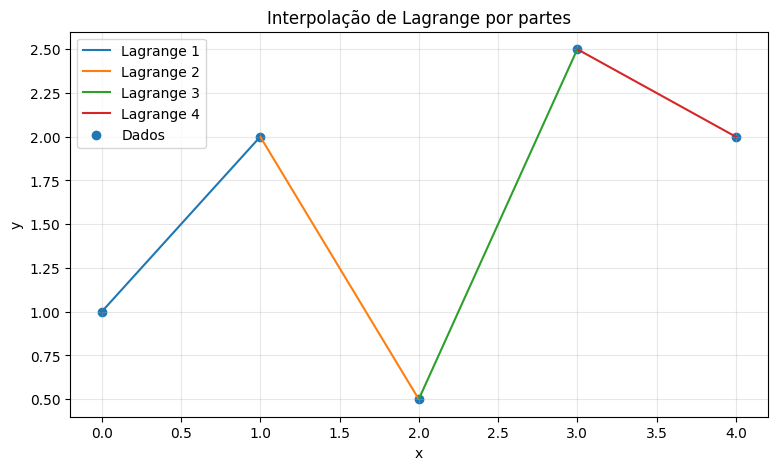

In [6]:
def lagrange_basis(x, xs, i):
    L = 1.0
    for j in range(len(xs)):
        if j != i:
            L *= (x - xs[j]) / (xs[i] - xs[j])
    return L

def lagrange_interp(x, xs, ys):
    total = 0.0
    for i in range(len(xs)):
        total += ys[i] * lagrange_basis(x, xs, i)
    return total

y_1 = lagrange_interp(x_plot[:150], x_data[:2], y_data[:2])
y_2 = lagrange_interp(x_plot[150:300], x_data[1:3], y_data[1:3])
y_3 = lagrange_interp(x_plot[300:450], x_data[2:4], y_data[2:4])
y_4 = lagrange_interp(x_plot[450:], x_data[3:], y_data[3:])

plt.figure(figsize=(9,5))
plt.plot(x_plot[:150], y_1, label="Lagrange 1")
plt.plot(x_plot[150:300], y_2, label="Lagrange 2")
plt.plot(x_plot[300:450], y_3, label="Lagrange 3")
plt.plot(x_plot[450:], y_4, label="Lagrange 4")
plt.scatter(x_data, y_data, label="Dados")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolação de Lagrange por partes")
plt.legend()
plt.show()  

### Comentário

A interpolação linear por partes:
- é simples;
- é estável;
- passa exatamente pelos pontos;

mas apresenta **quebras na inclinação**, isto é, não possui derivada contínua nas junções.

## 6. Introdução aos splines cúbicos

Um **spline cúbico** é uma função definida por partes, onde em cada subintervalo usamos um polinômio de grau 3:

\[
S_i(x)=a_i+b_i(x-x_i)+c_i(x-x_i)^2+d_i(x-x_i)^3.
\]

A ideia é combinar:
- **precisão local**;
- **suavidade global**.

## 7. Condições que definem um spline cúbico

Para cada subintervalo $[x_i,x_{i+1}]$, o spline deve satisfazer:

### 1. Interpolação
$$
S_i(x_i)=y_i, \qquad S_i(x_{i+1})=y_{i+1}
$$

### 2. Continuidade da primeira derivada
$$
S_i'(x_{i+1})=S_{i+1}'(x_{i+1})
$$

### 3. Continuidade da segunda derivada
$$
S_i''(x_{i+1})=S_{i+1}''(x_{i+1})
$$

### 4. Condições de contorno
No spline natural:
$$
S''(x_0)=0, \qquad S''(x_n)=0
$$

## 8. Exemplo-base: spline cúbico natural

Vamos construir um spline cúbico para o mesmo conjunto de dados anterior.

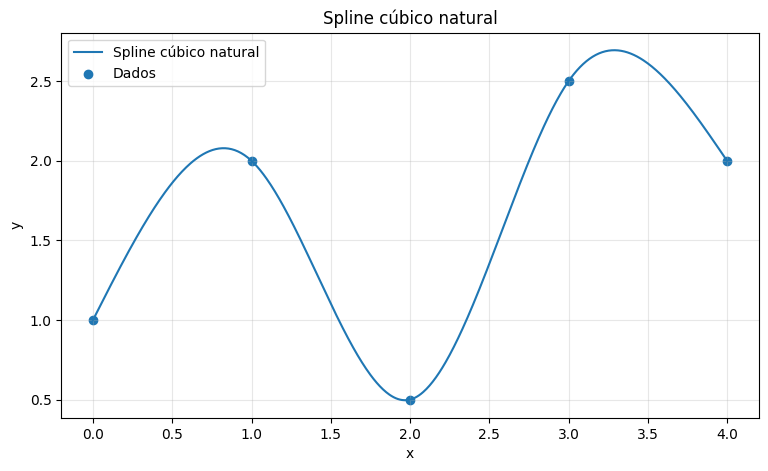

In [7]:
cs = CubicSpline(x_data, y_data, bc_type='natural')

x_plot = np.linspace(x_data.min(), x_data.max(), 600)
y_spline = cs(x_plot)

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_spline, label="Spline cúbico natural")
plt.scatter(x_data, y_data, label="Dados")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Spline cúbico natural")
plt.legend()
plt.show()

### Comentário

O spline cúbico:
- passa exatamente pelos dados;
- evita oscilações globais excessivas;
- produz uma curva mais suave do que a interpolação linear.

## 9. Comparação: linear por partes × spline cúbico

Esse é um gráfico excelente para os slides da apresentação.

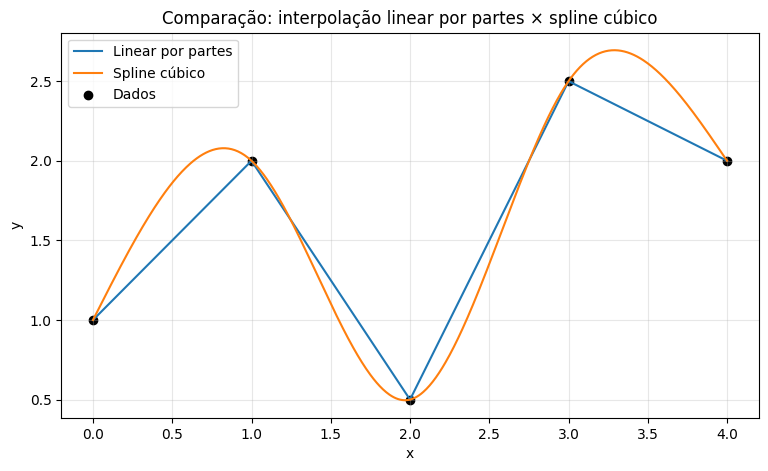

In [8]:
plt.figure(figsize=(9,5))
plt.plot(x_plot, y_linear, label="Linear por partes")
plt.plot(x_plot, y_spline, label="Spline cúbico")
plt.scatter(x_data, y_data, color="black", label="Dados")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparação: interpolação linear por partes × spline cúbico")
plt.legend()
plt.show()

## 10. Visualizando a suavidade: primeira e segunda derivadas

Uma grande vantagem dos splines cúbicos é a continuidade das derivadas.

Vamos visualizar:
- o spline;
- sua primeira derivada;
- sua segunda derivada.

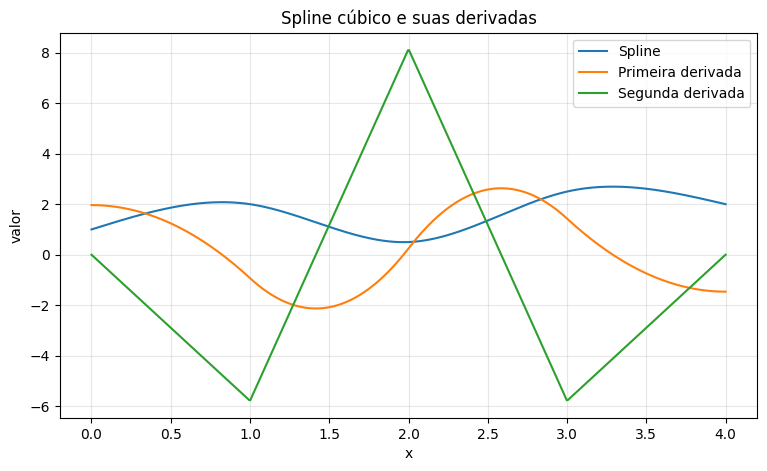

In [9]:
y1 = cs(x_plot, 1)
y2 = cs(x_plot, 2)

plt.figure(figsize=(9,5))
plt.plot(x_plot, y_spline, label="Spline")
plt.plot(x_plot, y1, label="Primeira derivada")
plt.plot(x_plot, y2, label="Segunda derivada")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("valor")
plt.title("Spline cúbico e suas derivadas")
plt.legend()
plt.show()

### Interpretação para aula

- a função spline é contínua;
- a primeira derivada também é contínua;
- a segunda derivada também é contínua;
- isso torna o spline muito útil em aplicações físicas e geométricas.

## 11. Comparação direta: polinômio global × spline cúbico na função de Runge

Agora vamos comparar, no mesmo problema, a interpolação global e o spline cúbico.

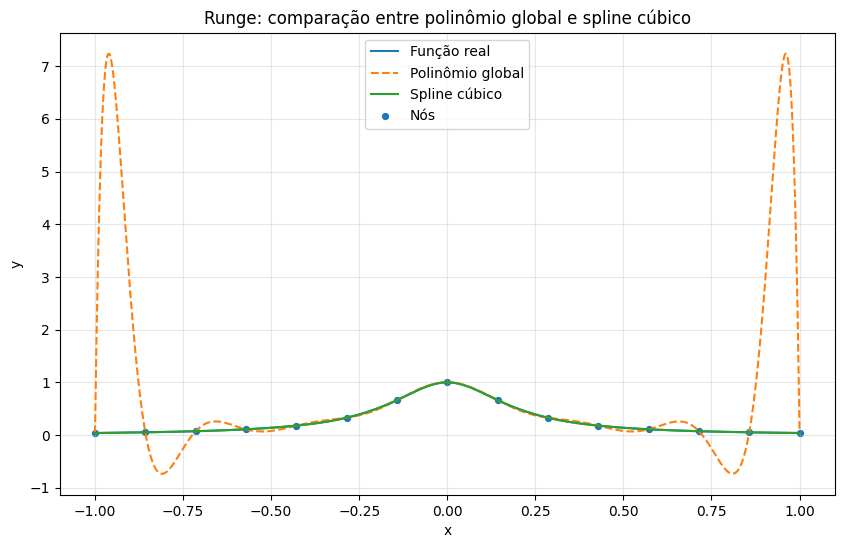

In [10]:
n = 15
xs = np.linspace(-1, 1, n)
ys = runge(xs)

coef_global = np.polyfit(xs, ys, deg=n-1)
p_global = np.poly1d(coef_global)

cs_runge = CubicSpline(xs, ys, bc_type='natural')

x_plot = np.linspace(-1, 1, 1500)
y_real = runge(x_plot)
y_global = p_global(x_plot)
y_spline = cs_runge(x_plot)

plt.figure(figsize=(10,6))
plt.plot(x_plot, y_real, label="Função real")
plt.plot(x_plot, y_global, "--", label="Polinômio global")
plt.plot(x_plot, y_spline, label="Spline cúbico")
plt.scatter(xs, ys, s=18, label="Nós")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Runge: comparação entre polinômio global e spline cúbico")
plt.legend()
plt.show()

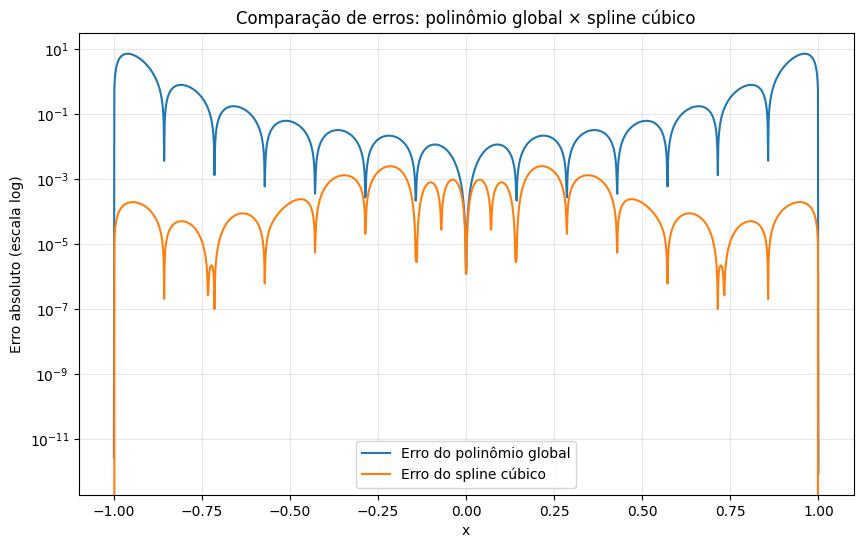

Erro máximo - polinômio global: 7.194641119170657
Erro máximo - spline cúbico: 0.0024827407269161217


In [11]:
erro_global = np.abs(y_real - y_global)
erro_spline = np.abs(y_real - y_spline)

plt.figure(figsize=(10,6))
plt.plot(x_plot, erro_global, label="Erro do polinômio global")
plt.plot(x_plot, erro_spline, label="Erro do spline cúbico")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.xlabel("x")
plt.ylabel("Erro absoluto (escala log)")
plt.title("Comparação de erros: polinômio global × spline cúbico")
plt.legend()
plt.show()

print("Erro máximo - polinômio global:", np.max(erro_global))
print("Erro máximo - spline cúbico:", np.max(erro_spline))

## 12. Aplicação em modelagem de dados

Em muitas situações experimentais, temos apenas medições discretas e queremos reconstruir uma curva suave.

Exemplo:
- temperatura ao longo do tempo;
- deslocamento de uma estrutura;
- posição de uma partícula;
- calibração de sensores.

A seguir, simulamos um conjunto de dados experimentais.

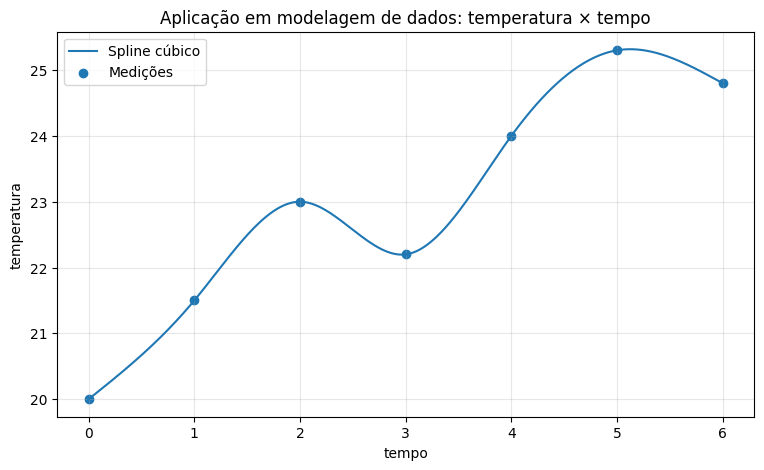

In [12]:
tempo = np.array([0, 1, 2, 3, 4, 5, 6], dtype=float)
temperatura = np.array([20.0, 21.5, 23.0, 22.2, 24.0, 25.3, 24.8], dtype=float)

cs_temp = CubicSpline(tempo, temperatura, bc_type='natural')
t_plot = np.linspace(tempo.min(), tempo.max(), 600)

plt.figure(figsize=(9,5))
plt.plot(t_plot, cs_temp(t_plot), label="Spline cúbico")
plt.scatter(tempo, temperatura, label="Medições")
plt.grid(True, alpha=0.3)
plt.xlabel("tempo")
plt.ylabel("temperatura")
plt.title("Aplicação em modelagem de dados: temperatura × tempo")
plt.legend()
plt.show()

### Discussão

Esse tipo de visualização é muito útil quando desejamos:
- estimar valores intermediários;
- construir curvas suaves;
- evitar oscilações artificiais de polinômios globais de alto grau.

## 13. Comparação com ajuste polinomial global em dados

Agora comparamos, para o mesmo conjunto de dados, um polinômio global de grau alto e um spline cúbico.

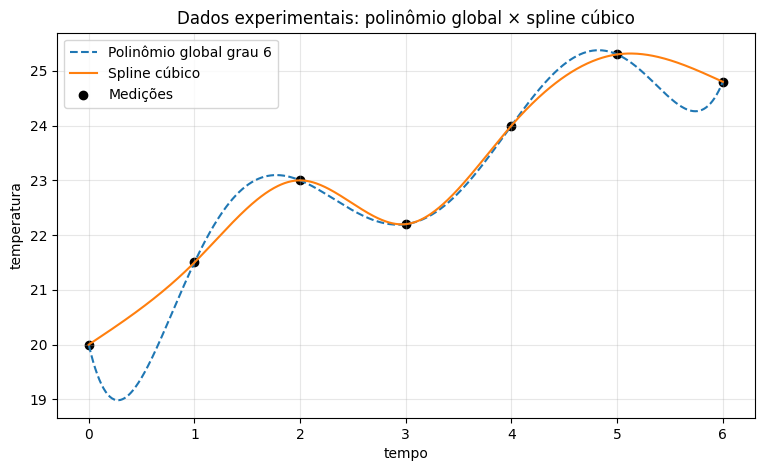

In [13]:
grau = len(tempo) - 1
coef_temp = np.polyfit(tempo, temperatura, deg=grau)
p_temp = np.poly1d(coef_temp)

plt.figure(figsize=(9,5))
plt.plot(t_plot, p_temp(t_plot), "--", label=f"Polinômio global grau {grau}")
plt.plot(t_plot, cs_temp(t_plot), label="Spline cúbico")
plt.scatter(tempo, temperatura, color="black", label="Medições")
plt.grid(True, alpha=0.3)
plt.xlabel("tempo")
plt.ylabel("temperatura")
plt.title("Dados experimentais: polinômio global × spline cúbico")
plt.legend()
plt.show()

## 14. Interpretação física e geométrica

Há uma interpretação clássica importante:

O spline cúbico natural pode ser visto como a curva que minimiza uma medida de curvatura, análoga à energia de flexão de uma viga elástica.

Por isso ele produz curvas:
- suaves;
- fisicamente plausíveis;
- muito úteis em modelagem e computação gráfica.

## 15. Exemplo complementar para slide: estrutura local dos polinômios do spline

Vamos mostrar que em cada subintervalo há um polinômio cúbico diferente.

In [14]:
print("Coeficientes do spline cúbico por intervalo:")
for i in range(len(cs.x) - 1):
    c3, c2, c1, c0 = cs.c[:, i]
    print(f"Intervalo [{cs.x[i]}, {cs.x[i+1]}]:")
    print(f"  S_{i}(x) = {c0:.6f} + {c1:.6f}(x-{cs.x[i]}) + {c2:.6f}(x-{cs.x[i]})^2 + {c3:.6f}(x-{cs.x[i]})^3")

Coeficientes do spline cúbico por intervalo:
Intervalo [0.0, 1.0]:
  S_0(x) = 1.000000 + 1.964286(x-0.0) + -0.000000(x-0.0)^2 + -0.964286(x-0.0)^3
Intervalo [1.0, 2.0]:
  S_1(x) = 2.000000 + -0.928571(x-1.0) + -2.892857(x-1.0)^2 + 2.321429(x-1.0)^3
Intervalo [2.0, 3.0]:
  S_2(x) = 0.500000 + 0.250000(x-2.0) + 4.071429(x-2.0)^2 + -2.321429(x-2.0)^3
Intervalo [3.0, 4.0]:
  S_3(x) = 2.500000 + 1.428571(x-3.0) + -2.892857(x-3.0)^2 + 0.964286(x-3.0)^3


## 16. Síntese da aula

Nesta aula vimos que:

1. a interpolação polinomial global pode falhar em problemas reais;
2. a interpolação por partes é uma alternativa mais robusta;
3. splines cúbicos combinam:
   - precisão local,
   - suavidade,
   - estabilidade;
4. eles são especialmente úteis em modelagem de dados;
5. a continuidade das derivadas é uma característica central dos splines.

## 17. Sugestões de exploração em sala

Você pode usar este notebook para:

- alterar os dados do exemplo experimental;
- comparar spline natural e spline com derivadas prescritas (`bc_type='clamped'`);
- testar diferentes quantidades de pontos na função de Runge;
- discutir custo computacional e sistemas tridiagonais;
- conectar com a próxima aula sobre ajuste e mínimos quadrados.